In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import yfinance as yf
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [2]:
'''
tickers = [
    "MSFT",
    "GOOGL",
    "NVDA",
    "AMZN",
    "AVGO",
    "JPM",
    "JNJ",
    "KO",
    "V",
    "LLY"
]
'''

tickers = [
    "MSFT",
    "GOOGL",
    "NVDA",
    "JNJ",
    "AMZN",
]

'''
tickers = [
    "JPM",
    "PG",    # Procter & Gamble
    "KO",    # Coca-Col   # PepsiCo
    "MCD",   # McDonald's
    "WMT",   # Walmart
    "COST",  # Costco
    "ABBV",  # AbbVie
    "CL"   # Merck
]
'''
full_data = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-01-01"
)

train_data = yf.download(
    tickers,
    start="2024-01-01",
    end="2025-01-01"
)


val_data = yf.download(
    tickers,
    start="2025-01-01",
    end="2026-01-01"
)

test_data = yf.download(
    tickers,
    start="2026-01-01",
    end="2027-01-01"
)

train_returns = train_data["Close"].pct_change().dropna()
val_returns = val_data["Close"].pct_change().dropna()
test_returns = test_data["Close"].pct_change().dropna()
full_returns = full_data['Close'].pct_change().dropna()

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  4 of 5 completed
[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  4 of 5 completed


In [3]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_returns)
val_scaled = scaler.transform(val_returns)
test_scaled = scaler.transform(test_returns)

full_scaler = StandardScaler()
full_scaled = full_scaler.fit_transform(full_returns)

In [4]:
def sequences(data, window):
    X = []
    y = []

    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [5]:
models = {}
histories = {}
preds = {}
mae_scores = {}
windows = [5, 10, 15, 20]

for window in windows:
    X_train, y_train = sequences(train_scaled, window)
    val_input = np.vstack([
        train_scaled[-window:],
        val_scaled
    ])
    X_val, y_val = sequences(val_input, window)
    model = Sequential()
    model.add(LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dense(len(tickers)))
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_val, y_val),
    )
    val_pred_scaled = model.predict(X_val)
    val_pred = scaler.inverse_transform(val_pred_scaled)
    val_true = scaler.inverse_transform(y_val)

    models[window] = model
    histories[window] = history
    preds[window] = (val_true, val_pred)
    mae_scores[window] = mean_absolute_error(val_true, val_pred)

D:\Users\Sofia\Documents\pycharm project\PythonProject\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 1.0211 - mae: 0.7420 - val_loss: 1.4040 - val_mae: 0.8146
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0099 - mae: 0.7381 - val_loss: 1.4047 - val_mae: 0.8145
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0013 - mae: 0.7357 - val_loss: 1.4071 - val_mae: 0.8150
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9949 - mae: 0.7337 - val_loss: 1.4085 - val_mae: 0.8153
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9895 - mae: 0.7320 - val_loss: 1.4118 - val_mae: 0.8161
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9848 - mae: 0.7308 - val_loss: 1.4128 - val_mae: 0.8166
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9802 - mae: 0.7293 - val_loss: 1.4151 - val_mae: 0.8173
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9757 - mae: 0.7279 - val_loss: 1.4166 - val_mae: 0.8179
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9722 - mae: 0.7267 - 

D:\Users\Sofia\Documents\pycharm project\PythonProject\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 1.0387 - mae: 0.7519 - val_loss: 1.4191 - val_mae: 0.8233
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0249 - mae: 0.7465 - val_loss: 1.4146 - val_mae: 0.8211
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0161 - mae: 0.7429 - val_loss: 1.4130 - val_mae: 0.8202
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0092 - mae: 0.7406 - val_loss: 1.4120 - val_mae: 0.8197
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.0037 - mae: 0.7385 - val_loss: 1.4123 - val_mae: 0.8200
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.9986 - mae: 0.7365 - val_loss: 1.4124 - val_mae: 0.8201
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9943 - mae: 0.7350 - val_loss: 1.4135 - val_mae: 0.8207
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9895 - mae: 0.7331 - val_loss: 1.4140 - val_mae: 0.8209
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.9855 - mae: 0.7315 - val_loss: 1

D:\Users\Sofia\Documents\pycharm project\PythonProject\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 1.0470 - mae: 0.7561 - val_loss: 1.4137 - val_mae: 0.8168
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.0342 - mae: 0.7509 - val_loss: 1.4117 - val_mae: 0.8157
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.0259 - mae: 0.7472 - val_loss: 1.4098 - val_mae: 0.8154
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.0201 - mae: 0.7448 - val_loss: 1.4100 - val_mae: 0.8157
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.0146 - mae: 0.7427 - val_loss: 1.4091 - val_mae: 0.8157
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0092 - mae: 0.7407 - val_loss: 1.4090 - val_mae: 0.8157
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0054 - mae: 0.7392 - val_loss: 1.4102 - val_mae: 0.8166
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0008 - mae: 0.7380 - val_loss: 1.4108 - val_mae: 0.8168
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9962 - mae: 0.7368 - val_loss: 1

D:\Users\Sofia\Documents\pycharm project\PythonProject\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 1.0379 - mae: 0.7490 - val_loss: 1.4022 - val_mae: 0.8147
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1.0268 - mae: 0.7455 - val_loss: 1.4009 - val_mae: 0.8141
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.0204 - mae: 0.7430 - val_loss: 1.4001 - val_mae: 0.8140
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.0153 - mae: 0.7412 - val_loss: 1.3998 - val_mae: 0.8146
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.0106 - mae: 0.7400 - val_loss: 1.4008 - val_mae: 0.8152
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.0068 - mae: 0.7388 - val_loss: 1.4027 - val_mae: 0.8155
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.0023 - mae: 0.7372 - val_loss: 1.4034 - val_mae: 0.8155
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.9980 - mae: 0.7352 - val_loss: 1.4050 - val_mae: 0.8159
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.9940 - mae: 0.7338 - val_loss: 1

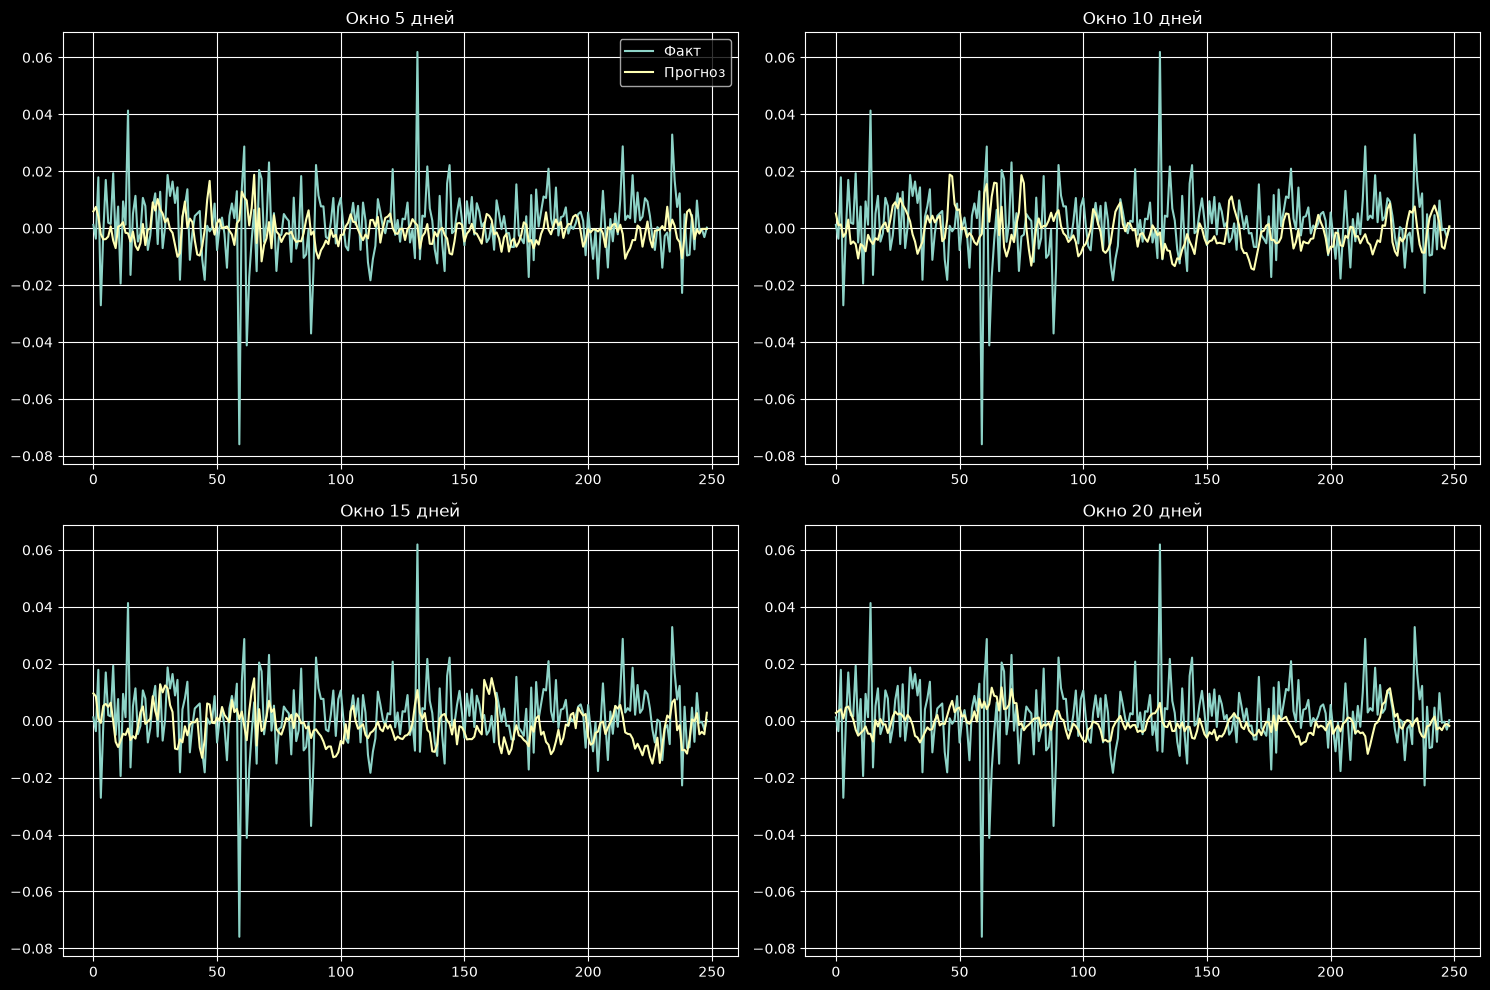

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

company = "NVDA"
idx = tickers.index(company)

for ax, window in zip(axes.flat, windows):

    true, pred = preds[window]

    ax.plot(true[:, idx], label="Факт")
    ax.plot(pred[:, idx], label="Прогноз")

    ax.set_title(f"Окно {window} дней")
    ax.grid(True)

axes[0, 0].legend()

plt.tight_layout()
plt.show()

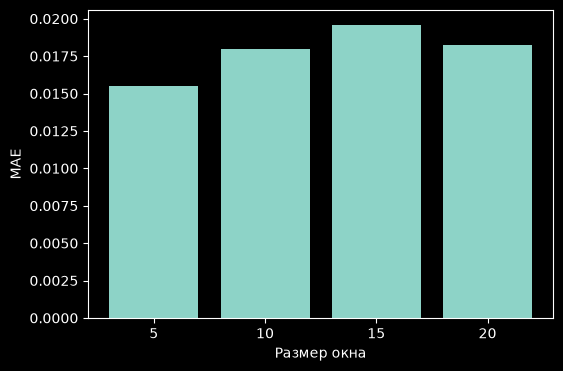

In [7]:
plt.figure(figsize=(6,4))

plt.bar(
    [str(w) for w in windows],
    [mae_scores[w] for w in windows]
)

plt.xlabel("Размер окна")
plt.ylabel("MAE")

plt.show()

In [8]:
direction_accuracy = np.mean(
    np.sign(val_pred) == np.sign(val_true),
    axis=0
)

for ticker, acc in zip(tickers, direction_accuracy):
    print(f"{ticker}: {acc:.2%}")

MSFT: 47.79%
GOOGL: 44.58%
NVDA: 49.40%
JNJ: 48.19%
AMZN: 55.42%


In [9]:
pred_direction = np.sign(val_pred)
true_direction = np.sign(val_true)

TP = np.sum((pred_direction > 0) & (true_direction > 0))
TN = np.sum((pred_direction < 0) & (true_direction < 0))
FP = np.sum((pred_direction > 0) & (true_direction < 0))
FN = np.sum((pred_direction < 0) & (true_direction > 0))

print("Рост угадан:", TP)
print("Падение угадано:", TN)
print("Рост ошибочно:", FP)
print("Падение ошибочно:", FN)

Рост угадан: 357
Падение угадано: 254
Рост ошибочно: 314
Падение ошибочно: 320


In [10]:
X_train, y_train = sequences(full_scaled, 20)

model = Sequential()
model.add(LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(len(tickers)))
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
)
last_window = full_scaled[-20:]
X_predict = np.expand_dims(
    last_window,
    axis=0
)

pred_scaled = model.predict(X_predict)
pred_return = full_scaler.inverse_transform(pred_scaled)
real_return = test_returns.iloc[0]

Epoch 1/15


D:\Users\Sofia\Documents\pycharm project\PythonProject\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.0142 - mae: 0.7111
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0003 - mae: 0.7079
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9927 - mae: 0.7061
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9858 - mae: 0.7050
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9795 - mae: 0.7036
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9727 - mae: 0.7015
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9713 - mae: 0.7016
Epoch 8/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9612 - mae: 0.6990
Epoch 9/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9551 - mae: 0.6968
Epoch 10/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9500 - mae: 0.6962
Epoch 11/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9416 - mae: 0.6950
Epoch 12/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9337 - mae: 0.6927
Epoch 13/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0

In [11]:

result = pd.DataFrame({
    "Компания": tickers,
    "Прогноз": pred_return.flatten(),
    "Факт": real_return.values
})

result["Ошибка"] = (
    result["Прогноз"] - result["Факт"]
).abs()

print(result)


  Компания   Прогноз      Факт    Ошибка
0     MSFT  0.002871  0.028962  0.026091
1    GOOGL  0.003241  0.004411  0.001169
2     NVDA  0.001220 -0.014661  0.015881
3      JNJ  0.002514 -0.000190  0.002704
4     AMZN  0.002853 -0.003866  0.006719


In [12]:
R = pred_return.mean(axis=0)
V = full_returns.cov().values
I = np.ones(len(tickers))
V_inv = np.linalg.inv(V)

In [13]:
alpha = I.T @ V_inv @ I
beta = I.T @ V_inv @ R
gamma = R.T @ V_inv @ R
delta = alpha * gamma - beta**2

In [14]:
sigma = 0.03

In [15]:
mu_0 = (
    beta / alpha
    +
    np.sqrt(
        ((sigma**2 - 1/alpha) / alpha) * delta
    )
)

In [16]:
W = V_inv @ (
    ((gamma - beta * mu_0) / delta)
    +
    ((alpha * mu_0 - beta) / delta) * R
)

In [17]:
# убираем короткие продажи

# нормализуем веса, чтобы сумма была равна 1
W = W / W.sum()

In [18]:
W.sum()

np.float64(1.0)

In [19]:
from scipy.optimize import minimize

R = pred_return.flatten()
V = full_returns.cov().values

sigma = 0.03

# функция доходности
def portfolio_return(W):
    return -(W @ R)  # минус, потому что minimize минимизирует

# ограничения
constraints = [
    {"type": "eq", "fun": lambda W: np.sum(W) - 1},   # сумма весов = 1
    {"type": "ineq", "fun": lambda W: sigma**2 - W.T @ V @ W}  # риск <= sigma
]

# веса от 0 до 1
bounds = [(0, 1)] * len(tickers)

# начальное приближение
W0 = np.ones(len(tickers)) / len(tickers)

result = minimize(
    portfolio_return,
    W0,
    bounds=bounds,
    constraints=constraints
)

W = result.x

In [20]:
portfolio = pd.DataFrame({
    "Компания": tickers,
    "Вес": W
})

portfolio

,Компания,Вес
0,MSFT,2.501975e-01
1,GOOGL,3.062852e-01
2,NVDA,2.775558e-17
3,JNJ,1.960557e-01
4,AMZN,2.474615e-01


In [21]:
portfolio_return = W @ R

portfolio_risk = np.sqrt(
    W.T @ V @ W
)

print(f"Средняя дневная доходность: {portfolio_return*100:.3f}%")
print("Риск:", portfolio_risk)

Средняя дневная доходность: 0.291%
Риск: 0.02028446603462174


In [22]:
portfolio_daily_returns = pred_return @ W

annual_return = np.prod(1 + portfolio_daily_returns) - 1

print(f"Ожидаемая годовая доходность: {annual_return*100:.2f}%")

Ожидаемая годовая доходность: 0.29%


In [23]:
real_annual_return = (
    test_data["Close"].iloc[-1] /
    test_data["Close"].iloc[0]
    - 1
)

real_annual = pd.DataFrame({
    "Компания": tickers,
    "Фактическая доходность": real_annual_return.values
})

print(real_annual)

  Компания  Фактическая доходность
0     MSFT                0.225077
1    GOOGL                0.133268
2     NVDA                0.249012
3      JNJ                0.069084
4     AMZN                0.189588


In [24]:
portfolio_real_return = np.sum(W * real_annual_return.values)

print(f"Фактическая годовая доходность: {portfolio_real_return*100:.2f}%")

Фактическая годовая доходность: 15.76%


In [25]:
predicted_annual_return = annual_return

error = abs(predicted_annual_return - portfolio_real_return)

print(f"Ошибка прогноза: {error*100:.2f}%")

Ошибка прогноза: 15.47%
